In [1]:
%load_ext autoreload
%autoreload 2

In [66]:
from pdf2image import convert_from_path

yellow_book_path = "data/the_yellow_book.pdf"
images = convert_from_path(yellow_book_path)

In [67]:
samples = images[19:21]

## Preprocess

In [68]:
from pipeline.preprocess import run_preprocess

In [69]:
preprocessed_images_for_ocr, preprocessed_images_for_table_rec, layout_result = run_preprocess(samples)


Recognizing layout: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it]


## Recognize Text

In [70]:
from pipeline.ocr import recognize_text

In [71]:
recognized_texts = recognize_text(preprocessed_images_for_ocr)

Recognizing Text: 100%|██████████| 85/85 [00:17<00:00,  4.80it/s]


## Recognize Tables

In [72]:
from pipeline.table_recognition import run_table_recognition

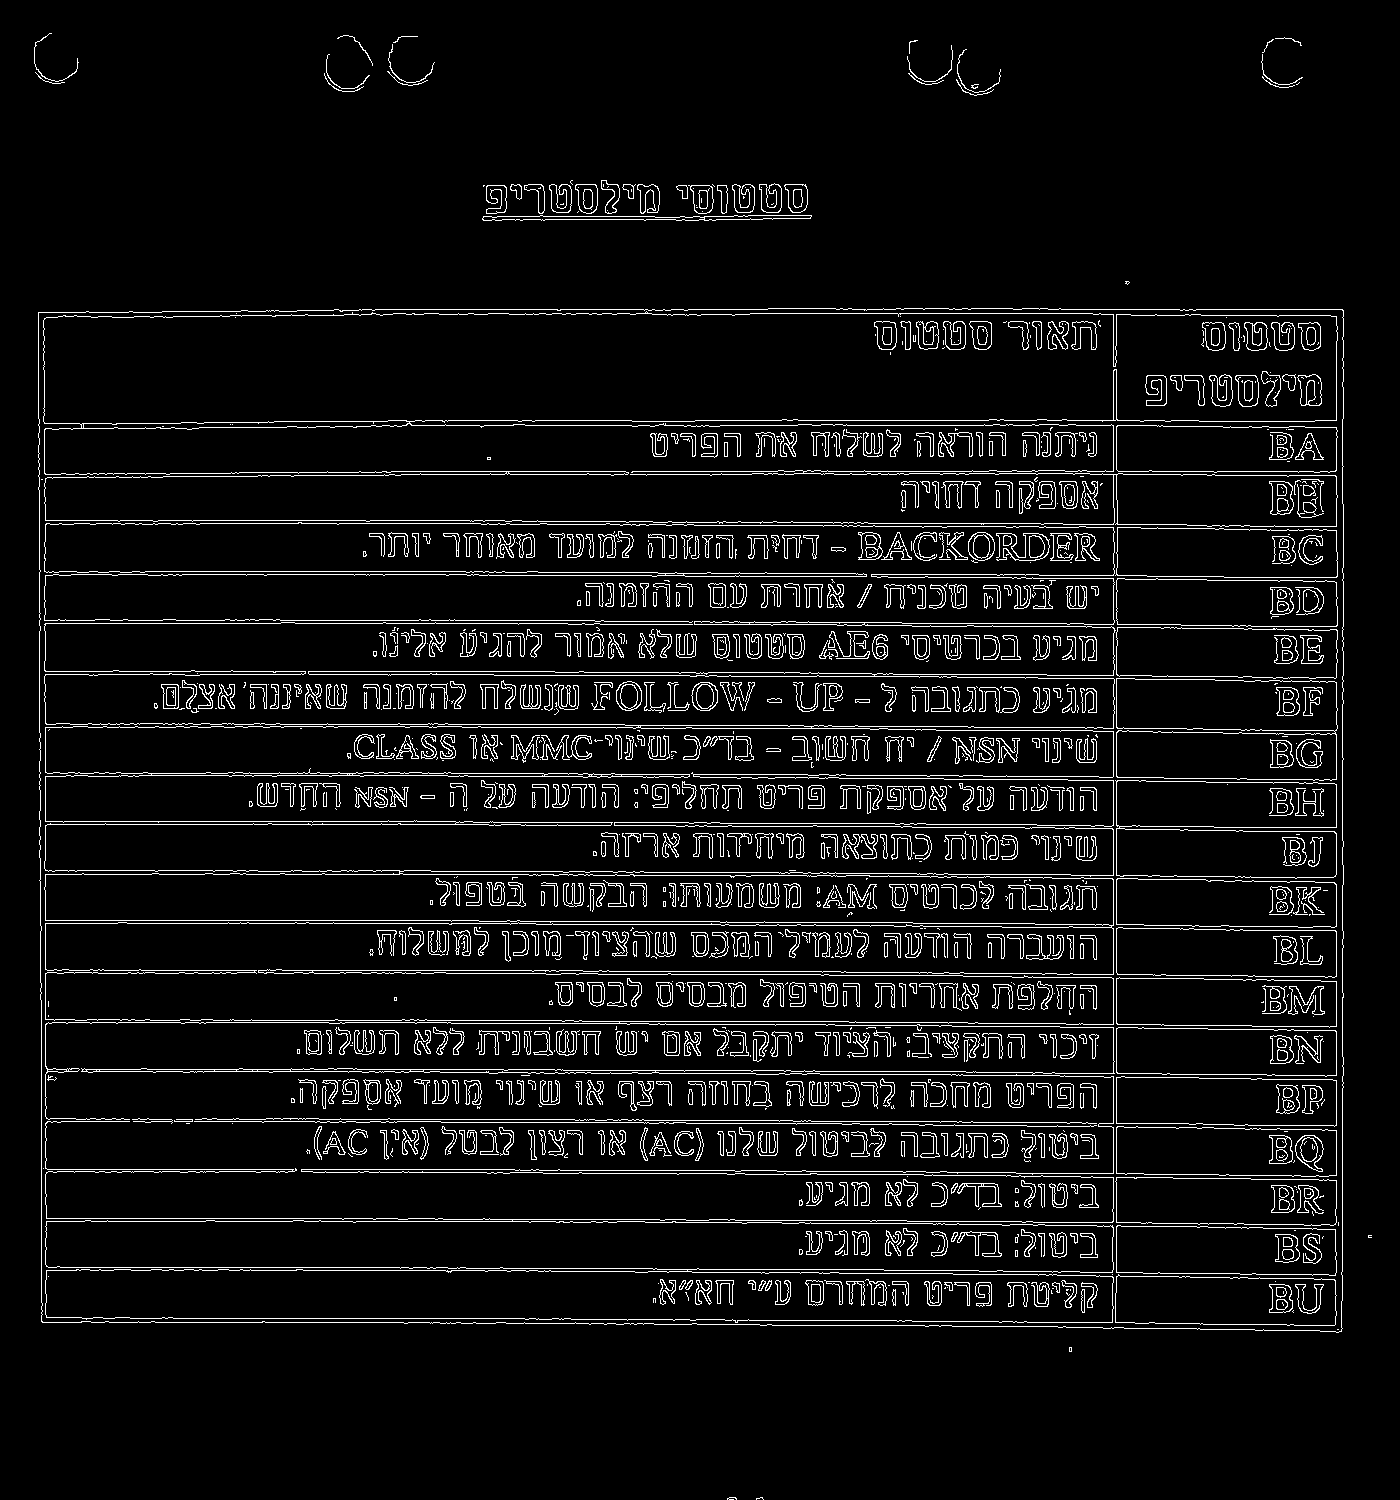

In [73]:
preprocessed_images_for_table_rec[0]

In [75]:
table_recognitions, table_bbox_coordinates = run_table_recognition(preprocessed_images_for_table_rec, layout_result)

Recognizing tables: 100%|██████████| 1/1 [00:00<00:00,  1.05it/s]


## Convert To PDF

In [76]:
from pipeline.pdf_utils import create_pdf
from pipeline.preprocess import DEFAULT_PAGE_LIMITS

In [77]:
top_left_x, top_left_y, bottom_right_x, bottom_right_y = DEFAULT_PAGE_LIMITS
w, h = bottom_right_x - top_left_x, bottom_right_y - top_left_y
create_pdf("samples_out.pdf", recognized_texts, table_recognitions, table_bbox_coordinates, w, h)

Created page 0
Created page 1
